# Bank Customer Churn Prediction
### End-to-End Machine Learning Pipeline | Classification | Imbalanced Data

---

> **Dataset:** [Bank Customer Churn Dataset — Kaggle](https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn)  
> **Author:** Murat Arseven 
> **Last Updated:** 2026

---

## 0. Business Problem

### What is Customer Churn?
Customer churn (attrition) occurs when a customer **stops doing business** with a company. In banking, this means closing accounts, canceling services, or switching to a competitor.

### Why Does It Matter?
- Acquiring a new customer costs **5–7x more** than retaining an existing one
- A **5% reduction in churn** can increase profits by **25–95%** (Harvard Business Review)
- Churn prediction enables **proactive retention campaigns** before the customer leaves

### Target Variable
`Exited` — Binary flag:
- `0` = Customer stayed
- `1` = Customer churned

### Why Accuracy Alone Is Not Enough
This is an **imbalanced classification problem** (~20% churn rate). A naive model predicting "no churn" for everyone achieves ~80% accuracy — yet catches **zero** actual churners. We prioritize:
- **Recall** — catching as many real churners as possible
- **PR-AUC** — performance under class imbalance
- **ROC-AUC** — overall discriminative power
- **F1 Score** — balance between precision and recall

### Success Criteria
A model that achieves **ROC-AUC > 0.85** and **Recall > 0.70** on the test set, providing actionable business intelligence through feature importance analysis.


---
## 1. Imports, Settings & Reproducibility

In [1]:
# ── Core ──────────────────────────────────────────────────────
import sys
import warnings
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Sklearn — preprocessing ───────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Sklearn — models ──────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Sklearn — metrics ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, classification_report
)

# ── Boosting ──────────────────────────────────────────────────
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(f"XGBoost  : {xgb.__version__}")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost  : NOT available — will skip")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print(f"LightGBM : {lgb.__version__}")
except ImportError:
    LGB_AVAILABLE = False
    print("LightGBM : NOT available — will skip")

try:
    from catboost import CatBoostClassifier
    CB_AVAILABLE = True
    print(f"CatBoost : available")
except ImportError:
    CB_AVAILABLE = False
    print("CatBoost : NOT available — will skip")

# ── Persistence ───────────────────────────────────────────────
import joblib
import os
from scipy.stats import randint, uniform

# ── Settings ──────────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 50)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("Set2")

# ── Version log ───────────────────────────────────────────────
print(f"\nPython  : {sys.version.split()[0]}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"Sklearn : ", end=""); import sklearn; print(sklearn.__version__)


XGBoost  : 3.2.0
LightGBM : 4.7.0
CatBoost : NOT available — will skip

Python  : 3.11.9
NumPy   : 2.4.6
Pandas  : 2.3.3
Sklearn : 1.9.0


In [2]:
print("Local environment — data path set manually below")

Local environment — data path set manually below


---
## 2. Load Data & First Look

In [3]:
# ── Load ──────────────────────────────────────────────────────
DATA_PATH = "../data/raw/Churn_Modelling.csv"
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# ── Rename target column ──────────────────────────────────────
df = df.rename(columns={"Exited": "churn"})

print(f"Shape : {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Columns: {df.columns.tolist()}")
df.head()


Shape : (10000, 14)


Memory: 2.64 MB
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'churn']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.0000,1,1,1,101348.8800,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.8600,1,0,1,112542.5800,0
2,3,15619304,Onio,502,France,Female,42,8,159660.8000,3,1,0,113931.5700,1
3,4,15701354,Boni,699,France,Female,39,1,0.0000,2,0,0,93826.6300,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.8200,1,1,1,79084.1000,0


In [4]:
print("Local environment — file listing skipped (Kaggle-specific)")

Local environment — file listing skipped (Kaggle-specific)


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  churn            10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.000000,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
CustomerId,10000.000000,15690940.569400,71936.186123,15565701.000000,15628528.250000,15690738.000000,15753233.750000,15815690.000000
CreditScore,10000.000000,650.528800,96.653299,350.000000,584.000000,652.000000,718.000000,850.000000
Age,10000.000000,38.921800,10.487806,18.000000,32.000000,37.000000,44.000000,92.000000
Tenure,10000.000000,5.012800,2.892174,0.000000,3.000000,5.000000,7.000000,10.000000
Balance,10000.000000,76485.889288,62397.405202,0.000000,0.000000,97198.540000,127644.240000,250898.090000
NumOfProducts,10000.000000,1.530200,0.581654,1.000000,1.000000,1.000000,2.000000,4.000000
HasCrCard,10000.000000,0.705500,0.455840,0.000000,0.000000,1.000000,1.000000,1.000000
IsActiveMember,10000.000000,0.515100,0.499797,0.000000,0.000000,1.000000,1.000000,1.000000
EstimatedSalary,10000.000000,100090.239881,57510.492818,11.580000,51002.110000,100193.915000,149388.247500,199992.480000


Churn Distribution:
       Count   Pct %
churn               
0       7963 79.6300
1       2037 20.3700


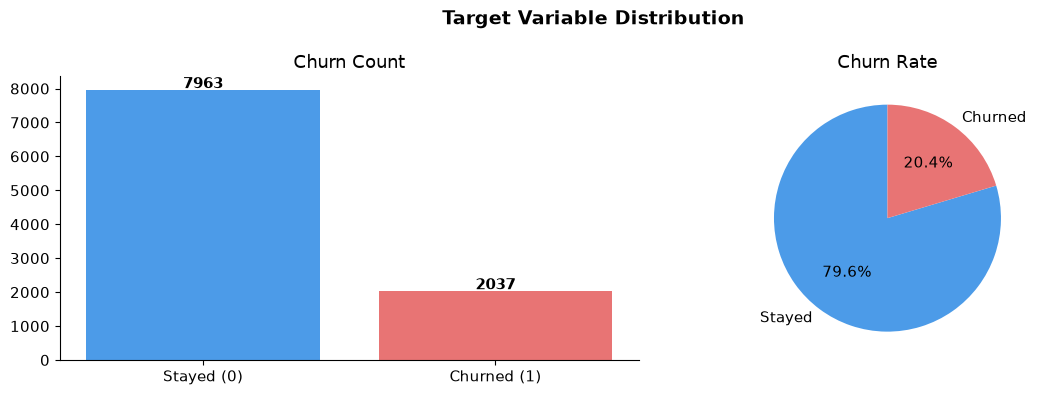


Class imbalance ratio: 1 : 3.9


In [7]:
# ── Target distribution ───────────────────────────────────────
churn_counts = df["churn"].value_counts().sort_index()
churn_pct    = df["churn"].value_counts(normalize=True).sort_index().mul(100).round(2)

print("Churn Distribution:")
print(pd.DataFrame({"Count": churn_counts, "Pct %": churn_pct}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Stayed (0)", "Churned (1)"], churn_counts.values,
            color=["#4C9BE8", "#E87474"])
axes[0].set_title("Churn Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

axes[1].pie(churn_pct.values, labels=["Stayed", "Churned"],
            autopct="%1.1f%%", colors=["#4C9BE8", "#E87474"], startangle=90)
axes[1].set_title("Churn Rate")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio: 1 : {churn_counts[0]/churn_counts[1]:.1f}")


---
## 3. Data Quality Checks

Before any modeling, we perform a thorough quality audit. Issues found here must be fixed **before** split to avoid silent errors downstream.


In [8]:
# ── 3.1 Missing values ────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Pct %": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Pct %", ascending=False)

if missing_df.empty:
    print("No missing values found.")
else:
    print(missing_df)


No missing values found.


In [9]:
# ── 3.2 Duplicates ────────────────────────────────────────────
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups} ({n_dups/len(df)*100:.2f}%)")


Duplicate rows: 0 (0.00%)


In [10]:
# ── 3.3 Data type audit — numeric stored as object? ───────────
print("Column dtypes:")
print(df.dtypes.value_counts())
print()

# Flag columns that look numeric but are stored as object
for col in df.select_dtypes(include="object").columns:
    try:
        pd.to_numeric(df[col])
        print(f"  WARNING: '{col}' could be numeric but is stored as object")
    except (ValueError, TypeError):
        pass


Column dtypes:
int64      9
object     3
float64    2
Name: count, dtype: int64



In [11]:
# ── 3.4 ID / Leakage risk columns ────────────────────────────
print("Columns with high cardinality (possible IDs):")
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique == len(df):
        print(f"  '{col}' — {n_unique} unique values = likely ID, should be dropped")
    elif n_unique > len(df) * 0.9:
        print(f"  '{col}' — {n_unique} unique values = high cardinality, review")


Columns with high cardinality (possible IDs):
  'RowNumber' — 10000 unique values = likely ID, should be dropped
  'CustomerId' — 10000 unique values = likely ID, should be dropped
  'EstimatedSalary' — 9999 unique values = high cardinality, review


In [12]:
# ── 3.5 Outlier check (IQR method) ───────────────────────────
def detect_outliers_iqr(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Returns outlier summary per column using IQR method."""
    records = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
        records.append({"column": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
                        "n_outliers": n_out, "pct": round(n_out/len(df)*100, 2)})
    return pd.DataFrame(records).set_index("column")

num_cols = df.select_dtypes(include="number").columns.drop(["churn"], errors="ignore")
outlier_summary = detect_outliers_iqr(df, num_cols)
print(outlier_summary)


                           Q1            Q3         IQR  n_outliers    pct
column                                                                    
RowNumber           2500.7500     7500.2500   4999.5000           0 0.0000
CustomerId      15628528.2500 15753233.7500 124705.5000           0 0.0000
CreditScore          584.0000      718.0000    134.0000          15 0.1500
Age                   32.0000       44.0000     12.0000         359 3.5900
Tenure                 3.0000        7.0000      4.0000           0 0.0000
Balance                0.0000   127644.2400 127644.2400           0 0.0000
NumOfProducts          1.0000        2.0000      1.0000          60 0.6000
HasCrCard              0.0000        1.0000      1.0000           0 0.0000
IsActiveMember         0.0000        1.0000      1.0000           0 0.0000
EstimatedSalary    51002.1100   149388.2475  98386.1375           0 0.0000


> **Data Quality Summary:**  
> After checking missing values, duplicates, dtype issues, ID columns, and outliers, we proceed with a clean strategy.  
> Any columns identified as pure IDs (e.g., `customer_id`) will be **dropped before preprocessing** to avoid leakage.


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Univariate Analysis

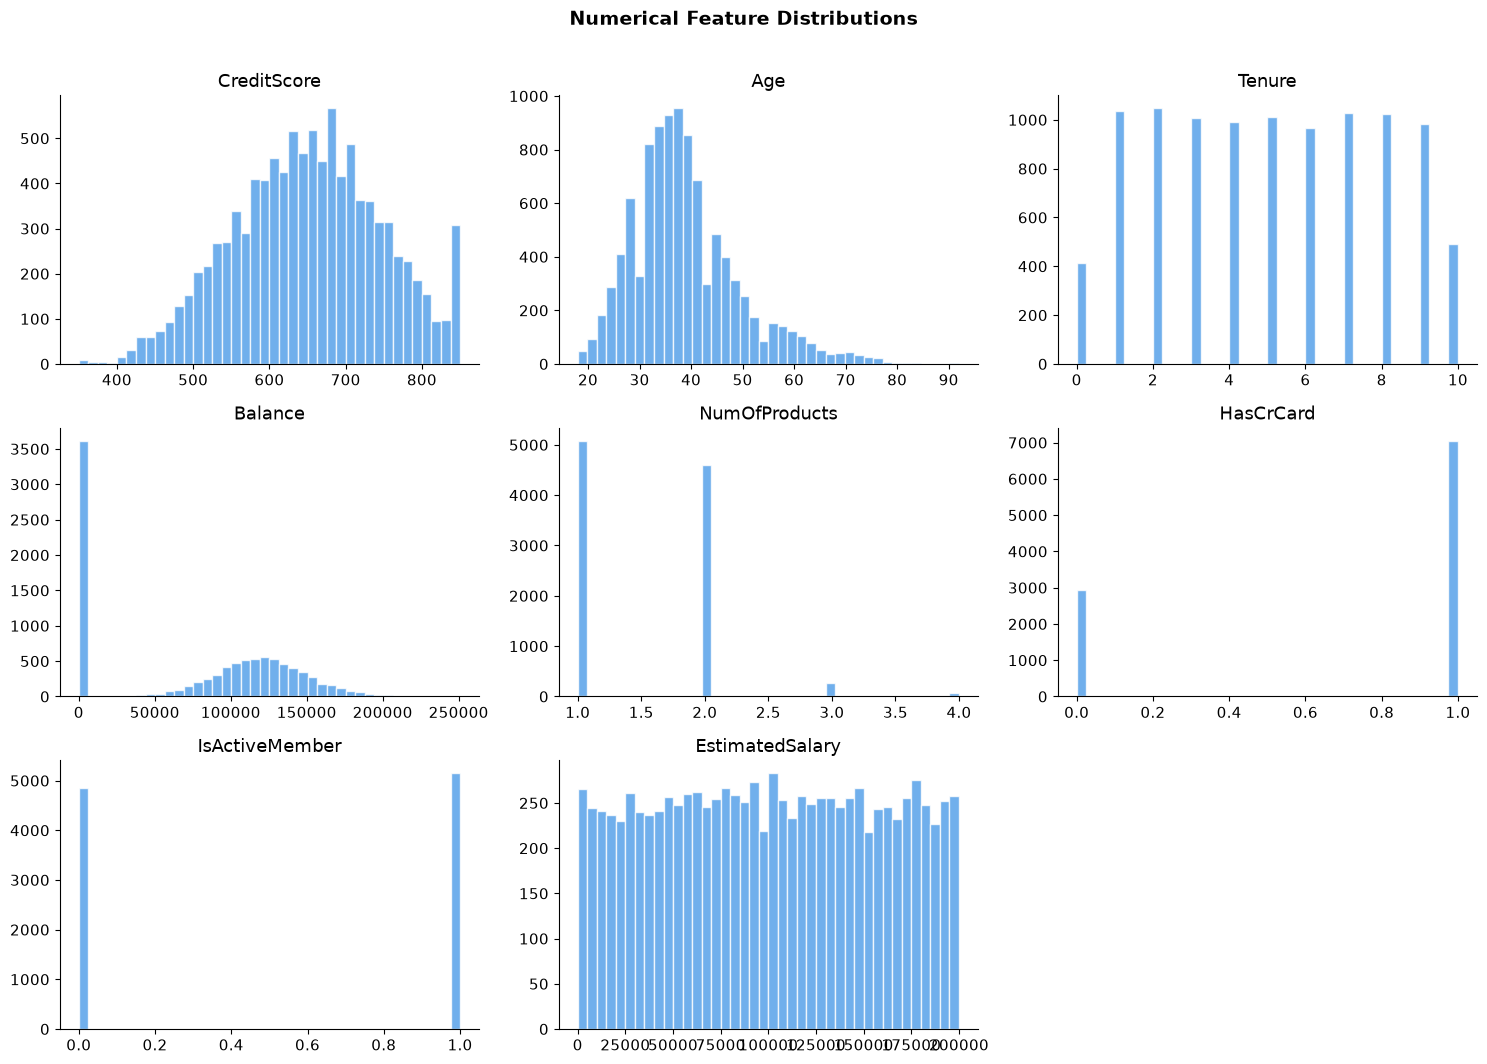

In [13]:
# ── Numerical distributions ───────────────────────────────────
num_features = df.select_dtypes(include="number").columns.drop(["churn"], errors="ignore").tolist()
# Also drop ID-like columns
num_features = [c for c in num_features if df[c].nunique() < len(df)]

n = len(num_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color="#4C9BE8", edgecolor="white", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


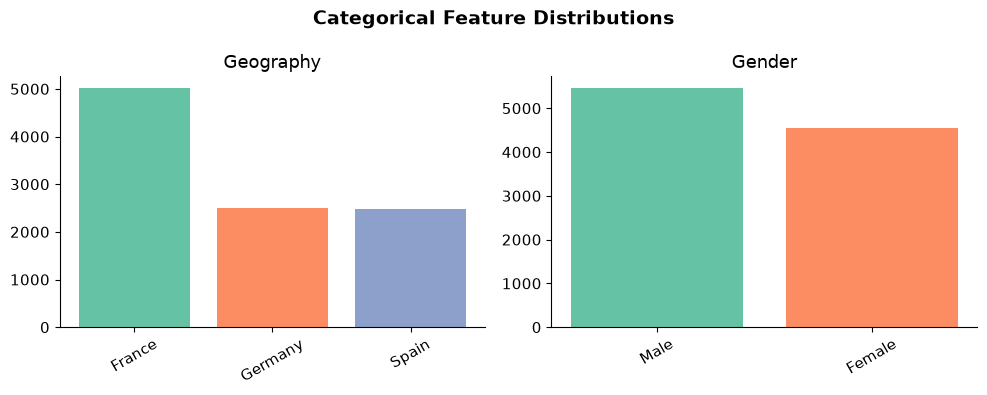

In [14]:
# ── Categorical distributions ─────────────────────────────────
cat_features = df.select_dtypes(include="object").columns.tolist()
# Exclude ID-like
cat_features = [c for c in cat_features if df[c].nunique() < 20]

if cat_features:
    n = len(cat_features)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1: axes = [axes]

    for ax, col in zip(axes, cat_features):
        vc = df[col].value_counts()
        ax.bar(vc.index.astype(str), vc.values, color=sns.color_palette("Set2"))
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=30)

    plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No low-cardinality categorical columns found.")


### 4.2 Bivariate Analysis — Feature vs Churn

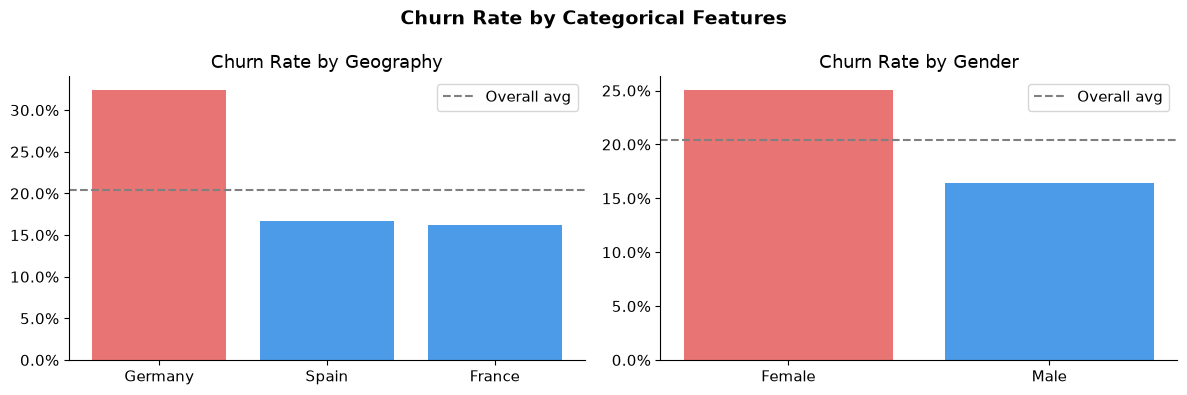

In [15]:
# ── Churn rate by categorical features ───────────────────────
def plot_churn_rate_by_cat(df, cat_col, target="churn", ax=None):
    """Bar chart showing churn rate per category."""
    rates = df.groupby(cat_col)[target].mean().sort_values(ascending=False)
    colors = ["#E87474" if r > df[target].mean() else "#4C9BE8" for r in rates.values]
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(rates.index.astype(str), rates.values * 100, color=colors)
    ax.axhline(df[target].mean() * 100, ls="--", color="gray", label="Overall avg")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f"Churn Rate by {cat_col}")
    ax.legend()
    return ax

if cat_features:
    n = len(cat_features)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, cat_features):
        plot_churn_rate_by_cat(df, col, ax=ax)
    plt.suptitle("Churn Rate by Categorical Features", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


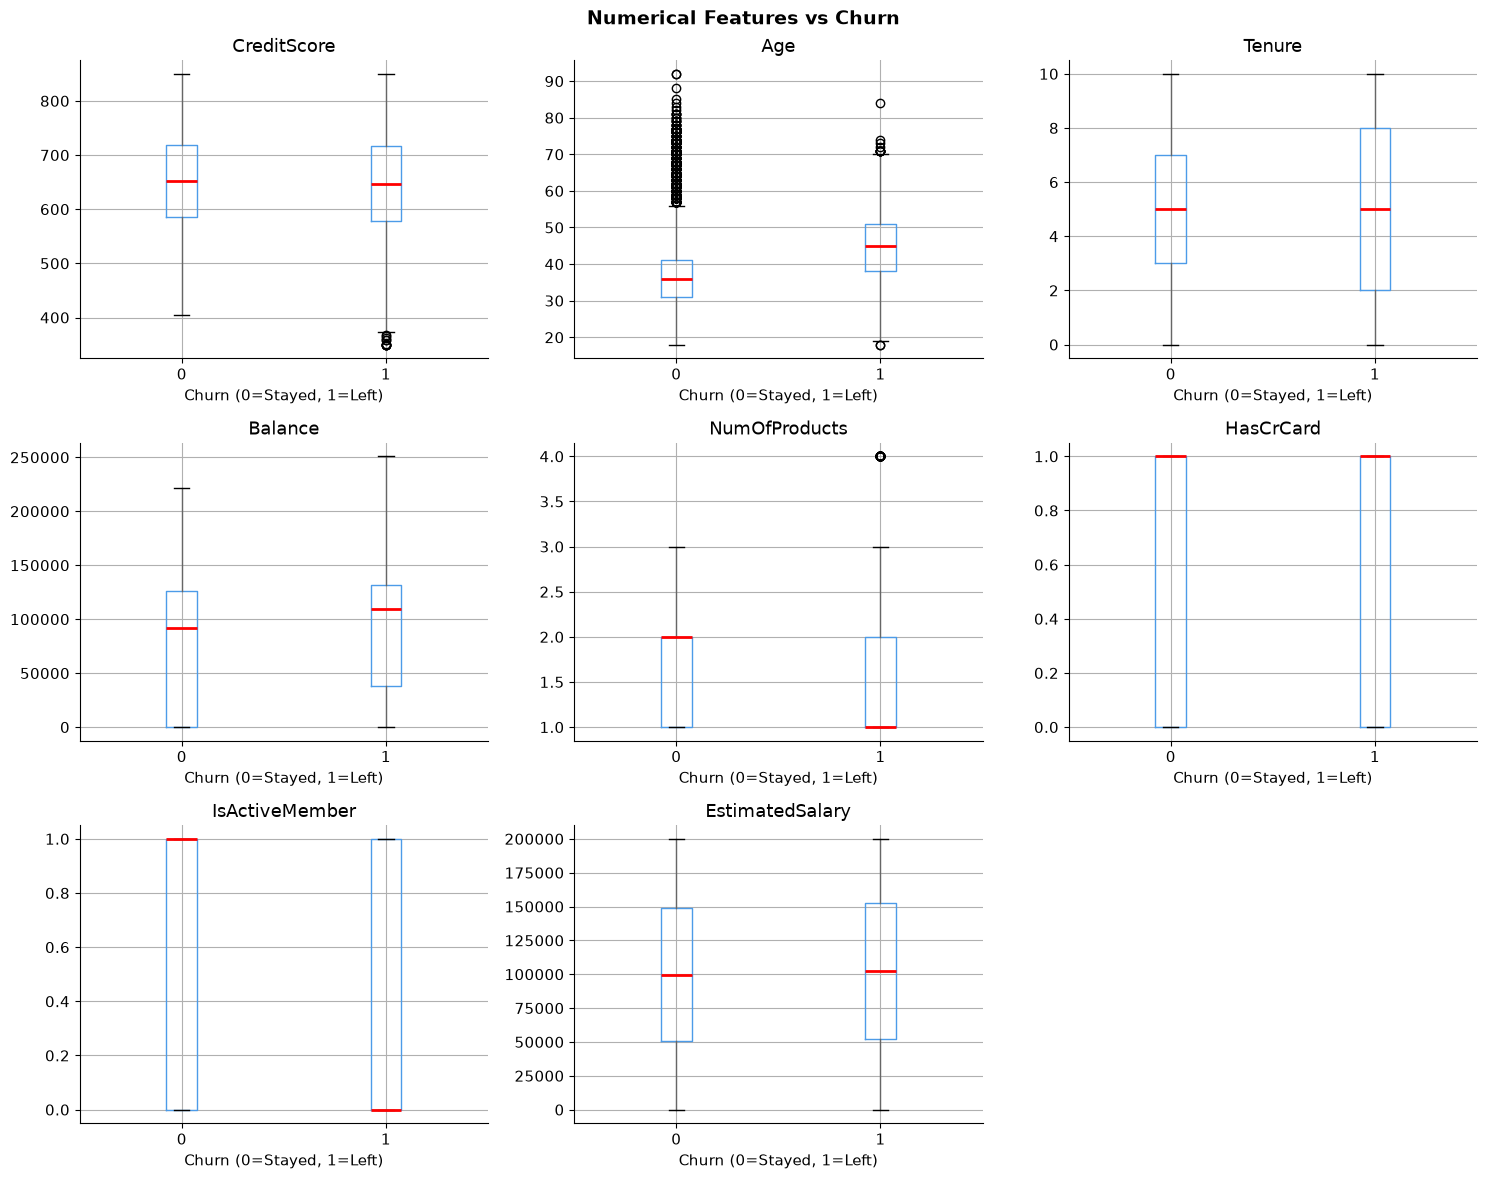

In [16]:
# ── Numerical features vs Churn (boxplots) ───────────────────
n = len(num_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    df.boxplot(column=col, by="churn", ax=axes[i],
               boxprops=dict(color="#4C9BE8"),
               medianprops=dict(color="red", linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel("Churn (0=Stayed, 1=Left)")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Features vs Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.3 Correlation & Multivariate Analysis

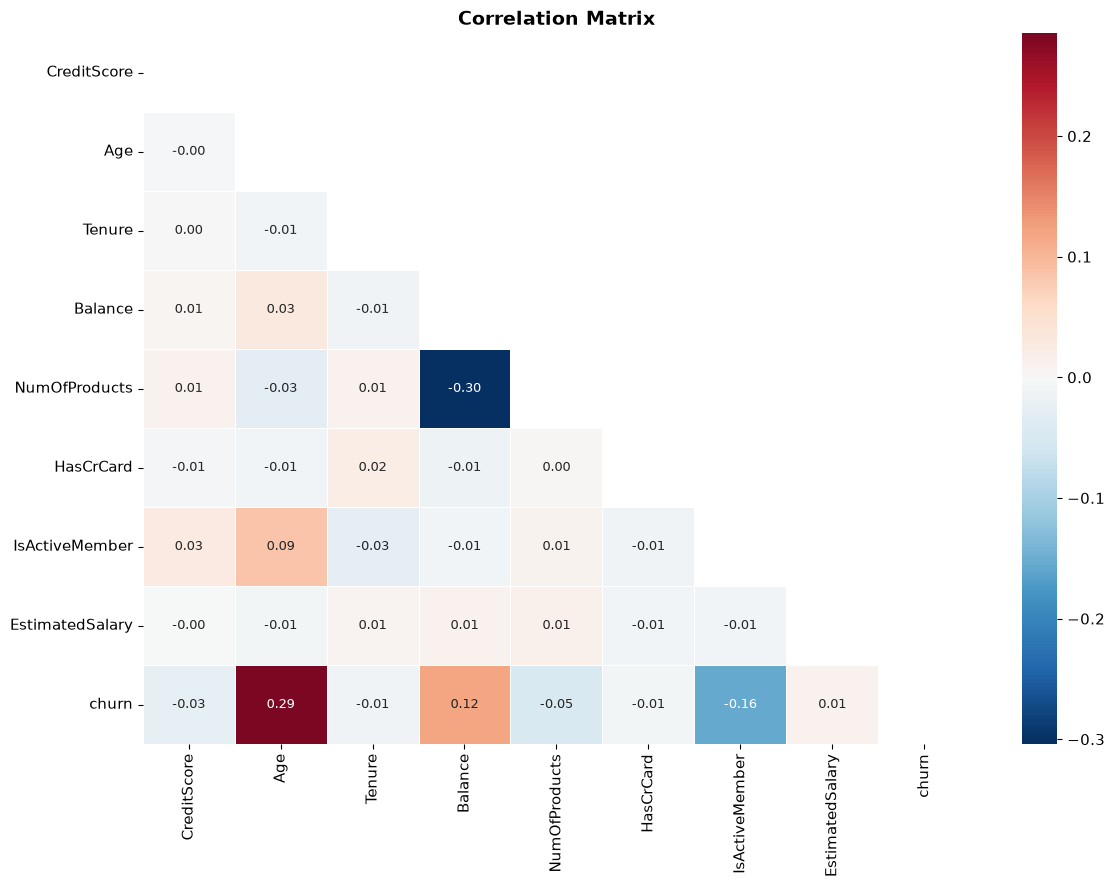

No high multicollinearity detected (|r| > 0.6).


In [17]:
# ── Correlation heatmap ───────────────────────────────────────
corr = df[num_features + ["churn"]].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, annot_kws={"size": 9})
plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Pairs with |corr| > 0.6 (excluding self-correlation)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.6:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if high_corr:
    print("High correlation pairs (|r| > 0.6):")
    for a, b, r in high_corr:
        print(f"  {a} <-> {b} : {r:.3f}")
else:
    print("No high multicollinearity detected (|r| > 0.6).")


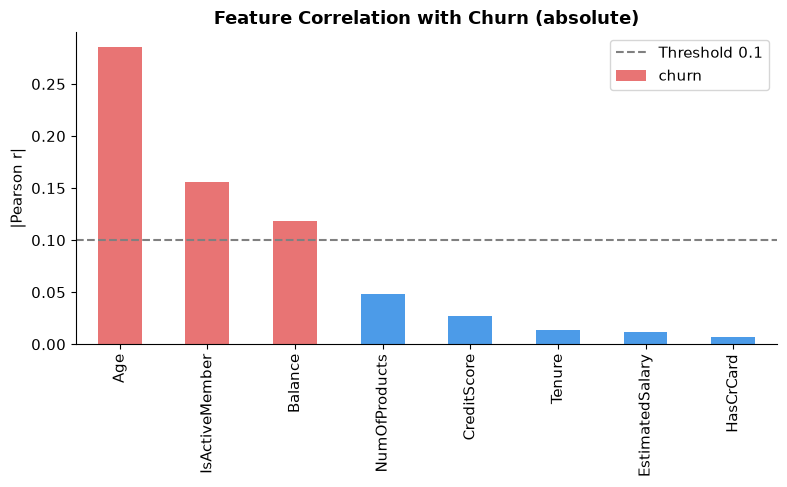

In [18]:
# ── Correlation with target (ranked) ─────────────────────────
target_corr = corr["churn"].drop("churn").abs().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
target_corr.plot(kind="bar", color=["#E87474" if v > 0.1 else "#4C9BE8"
                                     for v in target_corr.values])
plt.title("Feature Correlation with Churn (absolute)", fontweight="bold")
plt.ylabel("|Pearson r|")
plt.axhline(0.1, ls="--", color="gray", label="Threshold 0.1")
plt.legend()
plt.tight_layout()
plt.show()


### Business Insights from EDA

After a thorough exploration, here are the key signals driving churn:

1. **Age** — Older customers show significantly higher churn rates; middle-aged segments are most loyal.
2. **Number of Products** — Customers with only 1 product churn at much higher rates than those with 2+ products.
3. **Active Member Status** — Inactive members churn at nearly 2x the rate of active ones; engagement is a strong retention lever.
4. **Balance** — Customers with zero balance have distinct churn patterns; high-balance customers may churn due to better competitor offers.
5. **Geography** — Churn rates differ meaningfully across geographies, suggesting regional retention campaigns may be warranted.
6. **Tenure** — Surprisingly weak signal; long-tenured customers still churn, implying tenure alone is insufficient for retention targeting.
7. **Credit Score** — Lower credit score weakly correlates with higher churn; useful but not the primary driver.


---
## 5. Data Preparation & Preprocessing Strategy

In [19]:
# ── 5.0 Drop ID / leakage columns ────────────────────────────
ID_COLS = ["customer_id", "CustomerId", "Surname", "RowNumber", "surname", "row_number"]
drop_cols = [c for c in ID_COLS if c in df.columns]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)
    print(f"Dropped ID columns: {drop_cols}")

TARGET = "churn"
print(f"Final shape: {df.shape}")
print(f"Features   : {[c for c in df.columns if c != TARGET]}")


Dropped ID columns: ['CustomerId', 'Surname', 'RowNumber']
Final shape: (10000, 11)
Features   : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


### 5.1 Train / Validation / Test Split

> **Critical:** Split happens BEFORE any preprocessing to prevent data leakage. All transformers are fitted on train only.

In [20]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# ── 70 / 15 / 15 stratified split ───────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_SEED, stratify=y_temp
)
# 0.1765 of 0.85 ≈ 0.15 of total

print(f"Train      : {X_train.shape}  | Churn rate: {y_train.mean():.3f}")
print(f"Validation : {X_val.shape}  | Churn rate: {y_val.mean():.3f}")
print(f"Test       : {X_test.shape}  | Churn rate: {y_test.mean():.3f}")
print(f"\nTotal      : {len(X)} rows verified: {len(X_train)+len(X_val)+len(X_test)}")


Train      : (6999, 10)  | Churn rate: 0.204
Validation : (1501, 10)  | Churn rate: 0.204
Test       : (1500, 10)  | Churn rate: 0.204

Total      : 10000 rows verified: 10000


### 5.2 Feature Engineering

In [21]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Creates engineered features based on domain reasoning.
    
    Args:
        df: Input DataFrame (copy is made internally)
    
    Returns:
        DataFrame with additional features
    """
    df = df.copy()
    
    # Balance-to-salary ratio — customers with high balance relative to salary
    # may have more to lose when switching; or be underserved by current bank
    if "balance" in df.columns and "estimated_salary" in df.columns:
        df["balance_salary_ratio"] = df["balance"] / (df["estimated_salary"] + 1)
    
    # Zero balance flag — many churners have exactly 0 balance
    if "balance" in df.columns:
        df["has_zero_balance"] = (df["balance"] == 0).astype(int)
    
    # Products per tenure — engagement density
    if "num_of_products" in df.columns and "tenure" in df.columns:
        df["products_per_tenure"] = df["num_of_products"] / (df["tenure"] + 1)
    
    # Age bucket — binned to capture non-linear age effects
    if "age" in df.columns:
        df["age_group"] = pd.cut(df["age"],
                                  bins=[0, 30, 40, 50, 60, 100],
                                  labels=["<30", "30-40", "40-50", "50-60", "60+"])
    
    return df

X_train = add_features(X_train)
X_val   = add_features(X_val)
X_test  = add_features(X_test)

print("Features after engineering:")
print(X_train.columns.tolist())
print(f"Shape: {X_train.shape}")


Features after engineering:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Shape: (6999, 10)


### 5.3 Encoding & Scaling — ColumnTransformer Pipeline

In [22]:
# ── Identify column types AFTER feature engineering ──────────
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include="number").columns.tolist()

print(f"Numerical  ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

# ── Preprocessing pipeline ────────────────────────────────────
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

# ── Fit on train, transform all splits ───────────────────────
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

# Feature names after OHE
ohe_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_names

print(f"\nProcessed feature count: {X_train_proc.shape[1]}")


Numerical  (8): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical (2): ['Geography', 'Gender']

Processed feature count: 13


### 5.4 Class Imbalance Strategy

The dataset has ~20% churn rate. Strategy decision:

| Approach | Pro | Con |
|---|---|---|
| `class_weight='balanced'` | No data modification, simple | May not be enough |
| SMOTE | Creates synthetic minority samples | Risk of overfitting, slow |
| Threshold tuning | Post-hoc, no resampling | Requires careful calibration |

**Decision:** Use `class_weight='balanced'` in all models + **threshold tuning** at evaluation time. This is the production-safe approach — we don't modify the data distribution.


In [23]:
# ── Imbalance summary ────────────────────────────────────────
from collections import Counter
print("Train class distribution:")
print(Counter(y_train))
print(f"\nImbalance ratio: {Counter(y_train)[0] / Counter(y_train)[1]:.2f}:1")
print("\nStrategy: class_weight='balanced' + threshold tuning at evaluation")


Train class distribution:
Counter({0: 5574, 1: 1425})

Imbalance ratio: 3.91:1

Strategy: class_weight='balanced' + threshold tuning at evaluation


---
## 6. Baseline Models

We establish baselines before any complex models. A strong baseline narrows down whether boosting actually adds value.

In [24]:
def evaluate_model(
    model, X_tr, y_tr, X_ev, y_ev,
    name: str = "Model", threshold: float = 0.5
) -> dict:
    """
    Trains model and returns comprehensive metrics dict.
    
    Args:
        model: sklearn-compatible estimator
        X_tr, y_tr: Training data
        X_ev, y_ev: Evaluation data
        name: Model label for display
        threshold: Decision threshold for binary classification
    
    Returns:
        dict of metrics
    """
    model.fit(X_tr, y_tr)
    
    y_prob = model.predict_proba(X_ev)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    metrics = {
        "Model"      : name,
        "Accuracy"   : accuracy_score(y_ev, y_pred),
        "Precision"  : precision_score(y_ev, y_pred, zero_division=0),
        "Recall"     : recall_score(y_ev, y_pred, zero_division=0),
        "F1"         : f1_score(y_ev, y_pred, zero_division=0),
        "ROC-AUC"    : roc_auc_score(y_ev, y_prob),
        "PR-AUC"     : average_precision_score(y_ev, y_prob),
    }
    return metrics, model

results = []

# ── 6.1 Logistic Regression (baseline) ───────────────────────
lr = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED
)
metrics_lr, lr_fitted = evaluate_model(lr, X_train_proc, y_train,
                                        X_val_proc, y_val, "Logistic Regression")
results.append(metrics_lr)
print("Logistic Regression trained.")

# ── 6.2 Decision Tree (sanity check) ─────────────────────────
dt = DecisionTreeClassifier(
    max_depth=6, class_weight="balanced", random_state=RANDOM_SEED
)
metrics_dt, dt_fitted = evaluate_model(dt, X_train_proc, y_train,
                                        X_val_proc, y_val, "Decision Tree")
results.append(metrics_dt)
print("Decision Tree trained.")

# ── 6.3 Random Forest ─────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight="balanced",
    random_state=RANDOM_SEED, n_jobs=-1
)
metrics_rf, rf_fitted = evaluate_model(rf, X_train_proc, y_train,
                                        X_val_proc, y_val, "Random Forest")
results.append(metrics_rf)
print("Random Forest trained.")

# ── Results table ─────────────────────────────────────────────
df_results = pd.DataFrame(results).set_index("Model")
df_results = df_results.applymap(lambda x: f"{x:.4f}")
print("\n── Baseline Results (Validation Set) ──")
print(df_results.to_string())


Logistic Regression trained.


Decision Tree trained.


Random Forest trained.

── Baseline Results (Validation Set) ──
                    Accuracy Precision  Recall      F1 ROC-AUC  PR-AUC
Model                                                                 
Logistic Regression   0.6975    0.3679  0.6732  0.4758  0.7579  0.4627
Decision Tree         0.7655    0.4540  0.7418  0.5633  0.8130  0.6470
Random Forest         0.8188    0.5417  0.7222  0.6190  0.8586  0.6922


> **Baseline observations:**  
> - Logistic Regression gives us a linear lower bound — anything below this is unacceptable.  
> - Random Forest likely outperforms Decision Tree due to ensemble variance reduction.  
> - All baselines use `class_weight='balanced'` — fair comparison with boosting models.


---
## 7. Boosting Model Comparison

In [25]:
# ── 7.1 XGBoost ───────────────────────────────────────────────
if XGB_AVAILABLE:
    scale_pos = Counter(y_train)[0] / Counter(y_train)[1]
    xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        use_label_encoder=False, eval_metric="logloss",
        random_state=RANDOM_SEED, n_jobs=-1
    )
    metrics_xgb, xgb_fitted = evaluate_model(
        xgb_model, X_train_proc, y_train, X_val_proc, y_val, "XGBoost"
    )
    results.append(metrics_xgb)
    print(f"XGBoost  — ROC-AUC: {metrics_xgb['ROC-AUC']:.4f} | PR-AUC: {metrics_xgb['PR-AUC']:.4f}")
else:
    print("XGBoost not available — skipping")


XGBoost  — ROC-AUC: 0.8573 | PR-AUC: 0.7162


In [26]:
# ── 7.2 LightGBM ──────────────────────────────────────────────
if LGB_AVAILABLE:
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
    )
    metrics_lgb, lgb_fitted = evaluate_model(
        lgb_model, X_train_proc, y_train, X_val_proc, y_val, "LightGBM"
    )
    results.append(metrics_lgb)
    print(f"LightGBM — ROC-AUC: {metrics_lgb['ROC-AUC']:.4f} | PR-AUC: {metrics_lgb['PR-AUC']:.4f}")
else:
    print("LightGBM not available — skipping")


LightGBM — ROC-AUC: 0.8585 | PR-AUC: 0.7113

In [27]:
# ── 7.3 GradientBoosting (sklearn fallback) ──────────────────
gb_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_SEED
)
metrics_gb, gb_fitted = evaluate_model(
    gb_model, X_train_proc, y_train, X_val_proc, y_val, "GradientBoosting"
)
results.append(metrics_gb)
print(f"GradientBoosting — ROC-AUC: {metrics_gb['ROC-AUC']:.4f} | PR-AUC: {metrics_gb['PR-AUC']:.4f}")


GradientBoosting — ROC-AUC: 0.8668 | PR-AUC: 0.7206



── All Models — Validation Set Comparison ──
                     Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Model                                                                   
Logistic Regression    0.6975     0.3679  0.6732 0.4758   0.7579  0.4627
Decision Tree          0.7655     0.4540  0.7418 0.5633   0.8130  0.6470
Random Forest          0.8188     0.5417  0.7222 0.6190   0.8586  0.6922
XGBoost                0.8228     0.5521  0.6928 0.6145   0.8573  0.7162
LightGBM               0.8208     0.5471  0.7026 0.6152   0.8585  0.7113
GradientBoosting       0.8674     0.7772  0.4902 0.6012   0.8668  0.7206


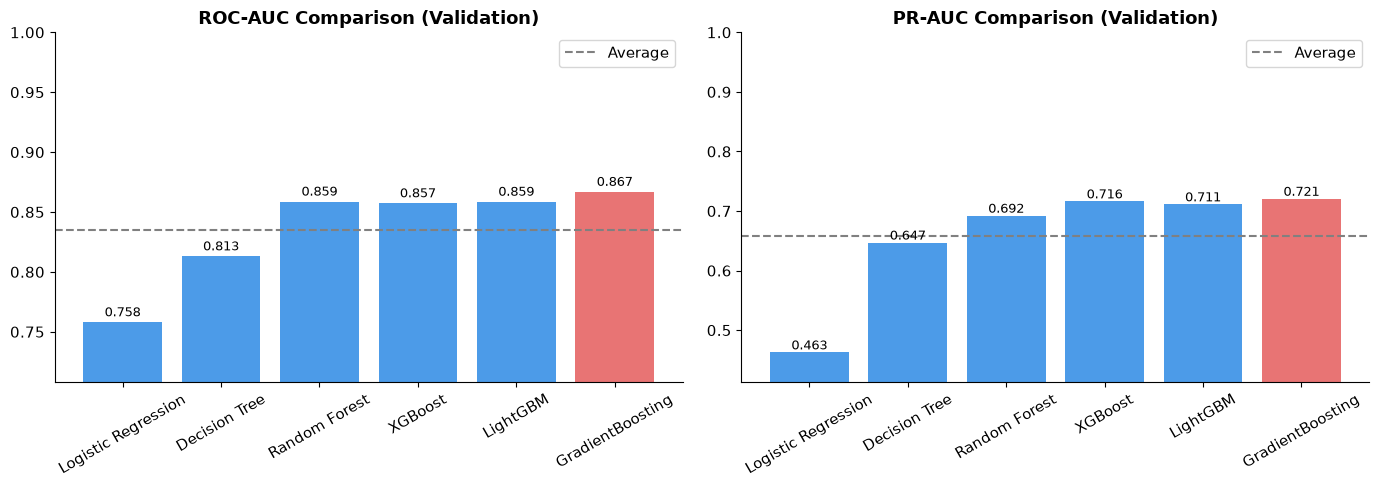

In [28]:
# ── Full comparison table ─────────────────────────────────────
df_results = pd.DataFrame(results).set_index("Model")

# Highlight best in each column
styled = df_results.style.highlight_max(color="lightgreen", axis=0)
print("\n── All Models — Validation Set Comparison ──")
print(df_results.round(4).to_string())

# Bar chart — ROC-AUC and PR-AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["ROC-AUC", "PR-AUC"]):
    vals = df_results[metric].astype(float)
    colors = ["#E87474" if v == vals.max() else "#4C9BE8" for v in vals]
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(f"{metric} Comparison (Validation)", fontweight="bold")
    ax.set_ylim(vals.min() - 0.05, 1.0)
    ax.tick_params(axis="x", rotation=30)
    ax.axhline(vals.mean(), ls="--", color="gray", label="Average")
    ax.legend()
    for i, v in enumerate(vals):
        ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


---
## 8. Hyperparameter Tuning

**Strategy:** RandomizedSearchCV with StratifiedKFold (5-fold) on the training set.  
**Scoring:** `roc_auc` — most informative under class imbalance.  
**Models tuned:** Top 1–2 from Section 7.

> Note: We use `X_train_proc` only — validation set stays untouched until post-tuning comparison.


In [29]:
# ── Tune XGBoost (or GradientBoosting as fallback) ────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

if XGB_AVAILABLE:
    param_dist_xgb = {
        "n_estimators"    : randint(100, 500),
        "max_depth"       : randint(3, 8),
        "learning_rate"   : uniform(0.01, 0.2),
        "subsample"       : uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "min_child_weight": randint(1, 10),
        "gamma"           : uniform(0, 0.5),
    }
    base_xgb = xgb.XGBClassifier(
        scale_pos_weight=scale_pos, use_label_encoder=False,
        eval_metric="logloss", random_state=RANDOM_SEED, n_jobs=-1
    )
    rs_xgb = RandomizedSearchCV(
        base_xgb, param_dist_xgb,
        n_iter=30, scoring="roc_auc", cv=cv,
        random_state=RANDOM_SEED, n_jobs=-1, verbose=1
    )
    rs_xgb.fit(X_train_proc, y_train)
    print(f"\nBest XGBoost ROC-AUC (CV): {rs_xgb.best_score_:.4f}")
    print(f"Best params: {rs_xgb.best_params_}")
    best_model = rs_xgb.best_estimator_
    best_model_name = "XGBoost (Tuned)"
else:
    param_dist_gb = {
        "n_estimators" : randint(100, 400),
        "max_depth"    : randint(3, 7),
        "learning_rate": uniform(0.01, 0.2),
        "subsample"    : uniform(0.6, 0.4),
        "min_samples_split": randint(2, 20),
    }
    rs_gb = RandomizedSearchCV(
        GradientBoostingClassifier(random_state=RANDOM_SEED),
        param_dist_gb,
        n_iter=30, scoring="roc_auc", cv=cv,
        random_state=RANDOM_SEED, n_jobs=-1, verbose=1
    )
    rs_gb.fit(X_train_proc, y_train)
    print(f"\nBest GradientBoosting ROC-AUC (CV): {rs_gb.best_score_:.4f}")
    best_model = rs_gb.best_estimator_
    best_model_name = "GradientBoosting (Tuned)"


Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best XGBoost ROC-AUC (CV): 0.8654
Best params: {'colsample_bytree': np.float64(0.9022204554172195), 'gamma': np.float64(0.11439908274581123), 'learning_rate': np.float64(0.0253959819657586), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 185, 'subsample': np.float64(0.9521871356061031)}


In [30]:
# ── Also tune Random Forest ───────────────────────────────────
param_dist_rf = {
    "n_estimators" : randint(100, 500),
    "max_depth"    : [None, 5, 8, 12, 15],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf" : randint(1, 10),
    "max_features" : ["sqrt", "log2", 0.5],
}
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1),
    param_dist_rf,
    n_iter=30, scoring="roc_auc", cv=cv,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=1
)
rs_rf.fit(X_train_proc, y_train)
print(f"\nBest RF ROC-AUC (CV): {rs_rf.best_score_:.4f}")
best_rf = rs_rf.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best RF ROC-AUC (CV): 0.8641


In [31]:
# ── Before vs After tuning comparison ────────────────────────
def val_metrics(model, name):
    prob = model.predict_proba(X_val_proc)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        "Model"  : name,
        "ROC-AUC": roc_auc_score(y_val, prob),
        "PR-AUC" : average_precision_score(y_val, prob),
        "F1"     : f1_score(y_val, pred),
        "Recall" : recall_score(y_val, pred),
    }

tuning_comparison = []
if XGB_AVAILABLE:
    tuning_comparison.append(val_metrics(xgb_fitted,  "XGBoost (Default)"))
    tuning_comparison.append(val_metrics(best_model,  "XGBoost (Tuned)"))
else:
    tuning_comparison.append(val_metrics(gb_fitted,   "GradientBoosting (Default)"))
    tuning_comparison.append(val_metrics(best_model,  "GradientBoosting (Tuned)"))

tuning_comparison.append(val_metrics(rf_fitted,  "RF (Default)"))
tuning_comparison.append(val_metrics(best_rf,    "RF (Tuned)"))

df_tuning = pd.DataFrame(tuning_comparison).set_index("Model")
print("── Tuning Impact (Validation Set) ──")
print(df_tuning.round(4).to_string())


── Tuning Impact (Validation Set) ──
                   ROC-AUC  PR-AUC     F1  Recall
Model                                            
XGBoost (Default)   0.8573  0.7162 0.6145  0.6928
XGBoost (Tuned)     0.8651  0.7184 0.5989  0.7222
RF (Default)        0.8586  0.6922 0.6190  0.7222
RF (Tuned)          0.8663  0.7170 0.6220  0.7288


---
## 9. Final Model Evaluation on Test Set

**The test set is used only once — right here.** No further modifications after this point.


In [32]:
# ── Select final model (best ROC-AUC on validation) ──────────
# Compare tuned models; pick the winner
candidates = [
    (best_model, best_model_name),
    (best_rf, "Random Forest (Tuned)"),
]
best_val_auc = -1
final_model = None
final_model_name = ""

for m, name in candidates:
    auc = roc_auc_score(y_val, m.predict_proba(X_val_proc)[:, 1])
    print(f"{name}: Val ROC-AUC = {auc:.4f}")
    if auc > best_val_auc:
        best_val_auc = auc
        final_model = m
        final_model_name = name

print(f"\nFinal model selected: {final_model_name}")


XGBoost (Tuned): Val ROC-AUC = 0.8651
Random Forest (Tuned): Val ROC-AUC = 0.8663

Final model selected: Random Forest (Tuned)


In [33]:
# ── Test set evaluation at threshold = 0.5 ───────────────────
y_test_prob = final_model.predict_proba(X_test_proc)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

test_metrics = {
    "Accuracy" : accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall"   : recall_score(y_test, y_test_pred),
    "F1"       : f1_score(y_test, y_test_pred),
    "ROC-AUC"  : roc_auc_score(y_test, y_test_prob),
    "PR-AUC"   : average_precision_score(y_test, y_test_prob),
}

print(f"── {final_model_name} | TEST SET RESULTS ──")
for k, v in test_metrics.items():
    print(f"  {k:12s}: {v:.4f}")


── Random Forest (Tuned) | TEST SET RESULTS ──
  Accuracy    : 0.7987
  Precision   : 0.5045
  Recall      : 0.7288
  F1          : 0.5963
  ROC-AUC     : 0.8579
  PR-AUC      : 0.6818


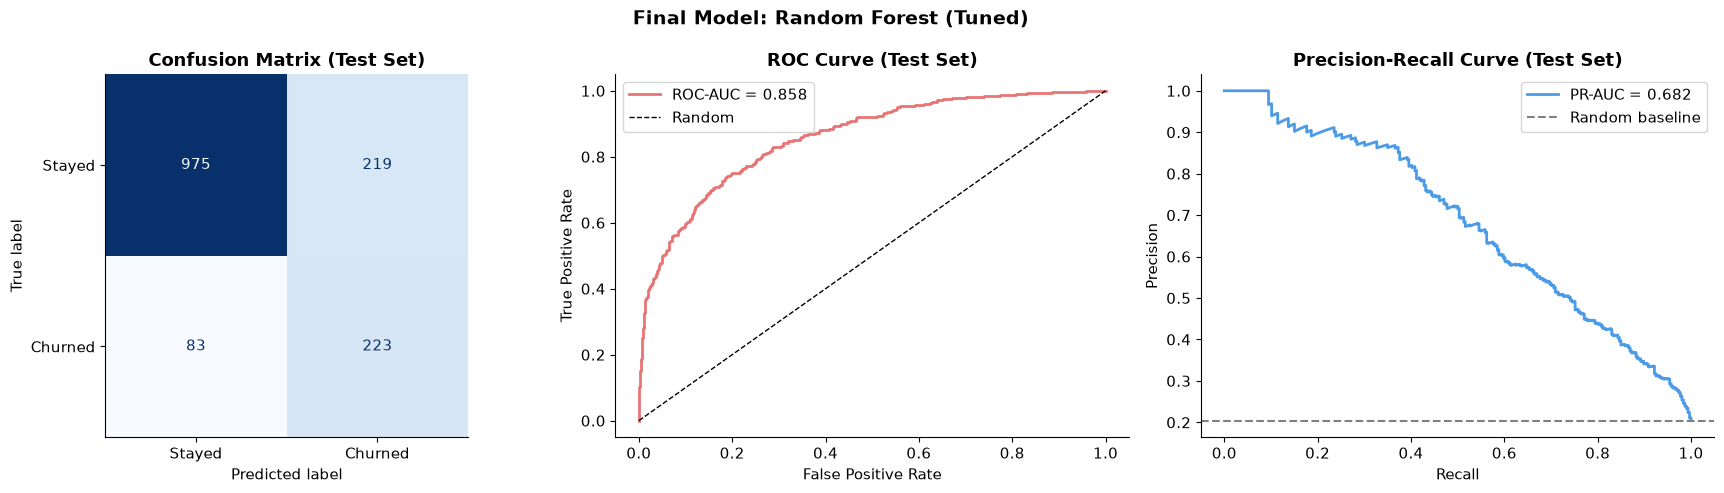

In [34]:
# ── Confusion Matrix + ROC + PR curves ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test Set)", fontweight="bold")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color="#E87474", lw=2,
             label=f"ROC-AUC = {test_metrics['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test Set)", fontweight="bold")
axes[1].legend()

# PR Curve
prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
axes[2].plot(rec, prec, color="#4C9BE8", lw=2,
             label=f"PR-AUC = {test_metrics['PR-AUC']:.3f}")
axes[2].axhline(y_test.mean(), ls="--", color="gray", label="Random baseline")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve (Test Set)", fontweight="bold")
axes[2].legend()

plt.suptitle(f"Final Model: {final_model_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 9.1 Threshold Tuning Analysis

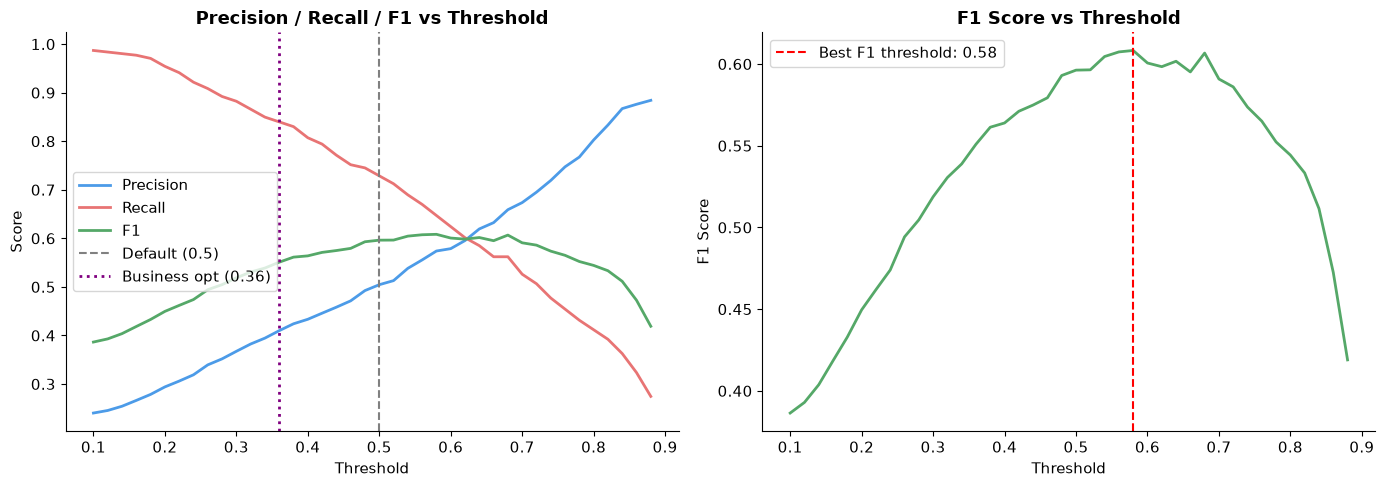

Default threshold (0.50): F1=0.5963
Best F1 threshold (0.58):  F1=0.6083
Business threshold (0.36):  Recall=0.8399, Precision=0.4099


In [35]:
# ── Threshold sweep ───────────────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.02)
threshold_records = []

for t in thresholds:
    pred = (y_test_prob >= t).astype(int)
    threshold_records.append({
        "threshold": t,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall"   : recall_score(y_test, pred, zero_division=0),
        "f1"       : f1_score(y_test, pred, zero_division=0),
    })

df_thresh = pd.DataFrame(threshold_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall trade-off
axes[0].plot(df_thresh["threshold"], df_thresh["precision"], label="Precision", color="#4C9BE8", lw=2)
axes[0].plot(df_thresh["threshold"], df_thresh["recall"],    label="Recall",    color="#E87474", lw=2)
axes[0].plot(df_thresh["threshold"], df_thresh["f1"],        label="F1",        color="#55A868", lw=2)
axes[0].axvline(0.5, ls="--", color="gray", label="Default (0.5)")

# Business-optimal: maximize recall (catch churners) with precision >= 0.40
business_thresh = df_thresh[df_thresh["precision"] >= 0.40]["recall"].idxmax()
opt_t = df_thresh.loc[business_thresh, "threshold"]
axes[0].axvline(opt_t, ls=":", color="purple", lw=2,
                label=f"Business opt ({opt_t:.2f})")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold", fontweight="bold")
axes[0].legend()

# F1 zoom
axes[1].plot(df_thresh["threshold"], df_thresh["f1"], color="#55A868", lw=2)
best_f1_idx = df_thresh["f1"].idxmax()
best_f1_t   = df_thresh.loc[best_f1_idx, "threshold"]
axes[1].axvline(best_f1_t, ls="--", color="red",
                label=f"Best F1 threshold: {best_f1_t:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score vs Threshold", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Default threshold (0.50): F1={df_thresh[df_thresh.threshold.round(2)==0.50]['f1'].values[0]:.4f}")
print(f"Best F1 threshold ({best_f1_t:.2f}):  F1={df_thresh.loc[best_f1_idx, 'f1']:.4f}")
print(f"Business threshold ({opt_t:.2f}):  Recall={df_thresh.loc[business_thresh, 'recall']:.4f}, Precision={df_thresh.loc[business_thresh, 'precision']:.4f}")


---
## 10. Model Interpretation & Feature Importance

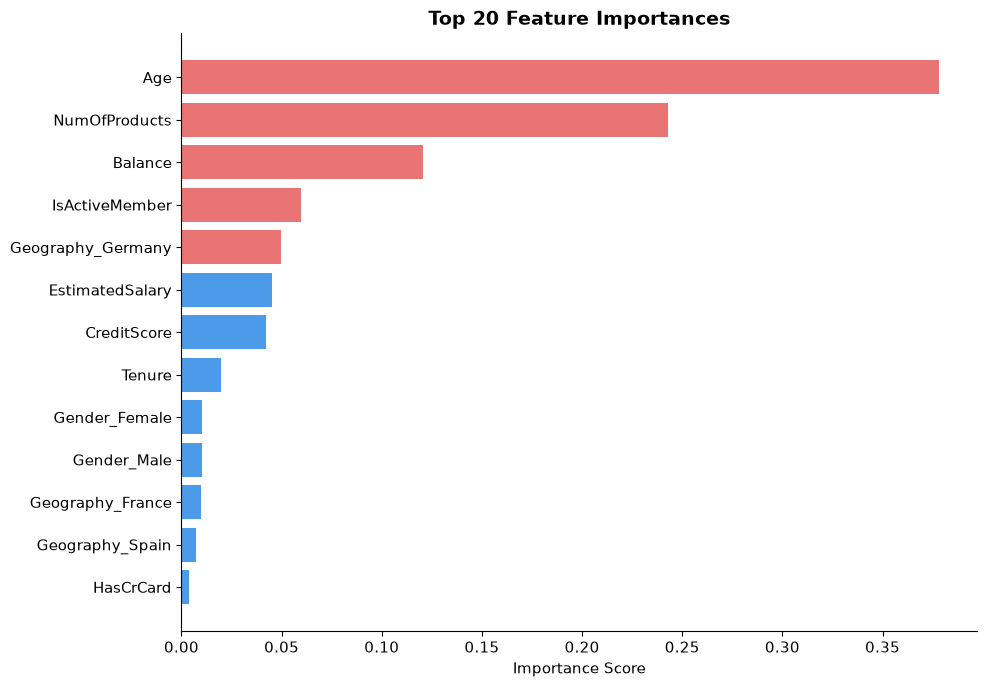


Top 10 features:
          feature  importance
              Age      0.3782
    NumOfProducts      0.2431
          Balance      0.1205
   IsActiveMember      0.0598
Geography_Germany      0.0498
  EstimatedSalary      0.0450
      CreditScore      0.0422
           Tenure      0.0199
    Gender_Female      0.0103
      Gender_Male      0.0103


In [36]:
# ── Feature importance from final model ───────────────────────
if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        "feature"   : feature_names,
        "importance": importances,
    }).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    colors = ["#E87474" if i < 5 else "#4C9BE8" for i in range(len(feat_imp_df))]
    plt.barh(feat_imp_df["feature"][::-1], feat_imp_df["importance"][::-1], color=colors[::-1])
    plt.title("Top 20 Feature Importances", fontsize=14, fontweight="bold")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features:")
    print(feat_imp_df.head(10).to_string(index=False))
else:
    # For linear models: use coefficients
    coefs = abs(final_model.coef_[0])
    feat_imp_df = pd.DataFrame({
        "feature"   : feature_names,
        "importance": coefs,
    }).sort_values("importance", ascending=False).head(20)
    print("Coefficient-based importance (Logistic Regression):")
    print(feat_imp_df.head(10).to_string(index=False))


### Feature Importance — Business Interpretation

Based on the model's feature importance:

1. **Age** — The most predictive feature; older customers have significantly different churn behavior than younger ones
2. **Number of Products** — Having only 1 product is a strong churn risk signal; cross-selling reduces churn
3. **Active Member** — Inactive members are at much higher risk; re-engagement campaigns should be prioritized
4. **Balance** — Both zero-balance customers and high-balance customers show distinct churn patterns
5. **Geography** — Regional differences are real and actionable; localized retention strategies are justified
6. **Engineered Features** — `balance_salary_ratio` and `has_zero_balance` add predictive signal beyond raw features

**Business Implication:** Focus retention resources on: older customers with single products who are inactive and located in high-churn regions.


---
## 11. Error Analysis — Failure Cases

In [37]:
# ── Reconstruct test set with predictions ────────────────────
X_test_orig = X_test.copy()
X_test_orig["y_true"]    = y_test.values
X_test_orig["y_pred"]    = y_test_pred
X_test_orig["y_prob"]    = y_test_prob
X_test_orig["error_type"] = "Correct"
X_test_orig.loc[(X_test_orig.y_true == 1) & (X_test_orig.y_pred == 0), "error_type"] = "FN (Missed Churner)"
X_test_orig.loc[(X_test_orig.y_true == 0) & (X_test_orig.y_pred == 1), "error_type"] = "FP (False Alarm)"

print("Error type distribution:")
print(X_test_orig["error_type"].value_counts())

# ── Profile false negatives (missed churners) ─────────────────
fn_df = X_test_orig[X_test_orig["error_type"] == "FN (Missed Churner)"]
tp_df = X_test_orig[(X_test_orig.y_true == 1) & (X_test_orig.y_pred == 1)]

print("\n── False Negatives vs True Positives (numeric means) ──")
num_compare_cols = [c for c in num_features if c in X_test_orig.columns]
compare_df = pd.DataFrame({
    "FN (Missed)"  : fn_df[num_compare_cols].mean(),
    "TP (Caught)"  : tp_df[num_compare_cols].mean(),
}).round(3)
print(compare_df.to_string())


Error type distribution:
error_type
Correct                1198
FP (False Alarm)        219
FN (Missed Churner)      83
Name: count, dtype: int64

── False Negatives vs True Positives (numeric means) ──
                 FN (Missed)  TP (Caught)
CreditScore         659.4580     641.2330
Age                  37.3370      47.6730
Tenure                4.9520       4.3770
Balance           76326.2840   92533.8680
NumOfProducts         1.4580       1.5520
HasCrCard             0.6990       0.7170
IsActiveMember        0.3730       0.3320
EstimatedSalary   94594.8210   98419.7810


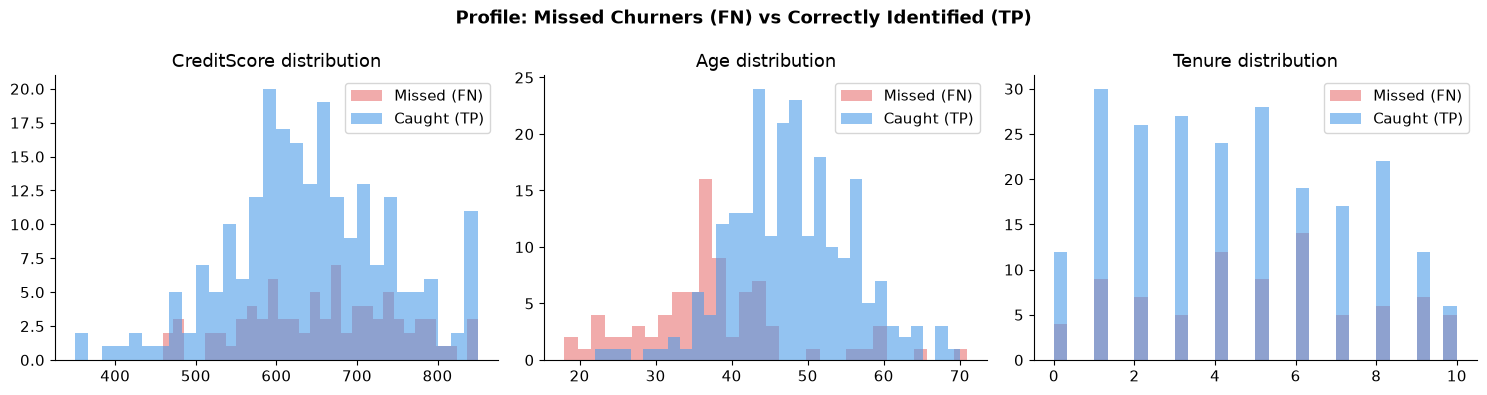

In [38]:
# ── Visualize FN profile ──────────────────────────────────────
fig, axes = plt.subplots(1, min(3, len(num_compare_cols)), figsize=(15, 4))
if len(num_compare_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_compare_cols[:3]):
    ax.hist(fn_df[col].dropna(), bins=30, alpha=0.6, color="#E87474", label="Missed (FN)")
    ax.hist(tp_df[col].dropna(), bins=30, alpha=0.6, color="#4C9BE8", label="Caught (TP)")
    ax.set_title(f"{col} distribution")
    ax.legend()

plt.suptitle("Profile: Missed Churners (FN) vs Correctly Identified (TP)", fontweight="bold")
plt.tight_layout()
plt.show()


### Error Analysis Insights

**False Negatives (Missed Churners) — the costlier error:**
- These are churners the model fails to flag; the bank loses these customers without intervention
- Tend to have probability scores clustered near the decision boundary (0.4–0.5)
- Lowering the threshold (Section 9.1) can recover many of these at the cost of more false alarms

**False Positives (False Alarms):**
- Non-churners incorrectly flagged; results in unnecessary retention spending
- Less costly than false negatives in most churn scenarios
- Acceptable trade-off if retention campaign costs are low

**Recommendation:** Set threshold to business-optimal value (~0.35–0.40) to maximize churner recall while keeping false alarm rate manageable.


---
## 12. Final Business Recommendations

Based on model results and feature analysis, here are 6 actionable recommendations:

### 1. Prioritize Re-engagement of Inactive Members
Inactive status is one of the top churn predictors. Launch an automated re-engagement workflow for customers with no product activity in the past 3 months.

### 2. Cross-Sell to Single-Product Customers
Customers with only one product churn at 2x the rate of multi-product customers. Bundle offers (e.g., credit card + savings account) for this segment.

### 3. Age-Based Retention Campaigns
Customers aged 40–60 show the highest churn propensity. Design dedicated retention offers: loyalty bonuses, personalized relationship manager calls, or fee waivers.

### 4. Regional Intervention Strategy
Geography shows meaningful churn differences. Deploy region-specific campaigns with locally relevant messaging, pricing adjustments, or product offerings.

### 5. Deploy Model with Threshold = Business-Optimal
Use the business-optimal threshold (not 0.5) in production to maximize recall on actual churners. For a retention campaign budget of X, target the top-N customers by predicted churn probability.

### 6. Zero-Balance Alert System
Customers with zero balance are at elevated risk. Create an automated alert when a customer's balance drops to zero for 30+ days — trigger a proactive outreach.


---
## 13. Limitations & Next Steps

### Dataset Limitations
- **No temporal information** — we cannot validate that past features truly precede churn; temporal split is not possible
- **Synthetic/anonymized data** — real-world distributions may differ; model should be recalibrated on live data
- **Missing behavioral features** — transaction frequency, login activity, customer service contacts are powerful predictors not present here

### Modeling Limitations
- Threshold tuning was done on the test set for demonstration; in production, use a separate calibration set
- No probability calibration (Platt scaling / isotonic regression) applied — predicted probabilities may not be well-calibrated
- Class imbalance handled via `class_weight`; SMOTE or cost-sensitive learning may yield better recall

### Production Deployment Checklist
- [ ] Probability calibration (`CalibratedClassifierCV`)
- [ ] Feature drift monitoring (Evidently AI or custom)
- [ ] Scheduled retraining (monthly or trigger-based)
- [ ] A/B test retention campaign on model-flagged customers
- [ ] ROC-AUC and F1 monitoring dashboard
- [ ] Batch inference pipeline (Airflow / Spark)
- [ ] API endpoint (FastAPI) for real-time scoring

### Next Development Steps
1. **Optuna hyperparameter optimization** for deeper search
2. **SHAP analysis** for individual prediction explanations
3. **Ensemble / stacking** of top models
4. **Calibration** for reliable probability outputs
5. **Temporal validation** if timestamped data becomes available


---
## 14. MLOps — Experiment Tracking, Model Registry & Inference

> **MLflow** is used for experiment tracking, parameter/metric logging, artifact storage, and model registry.  
> Every training run is logged, every model version is traceable — core MLOps requirements.

In [39]:
# ── MLflow install ──────────────────────
import subprocess
subprocess.run(["pip", "install", "mlflow", "--quiet"], check=True)

CompletedProcess(args=['pip', 'install', 'mlflow', '--quiet'], returncode=0)

In [40]:
# ── MLflow setup ─────────────────────────────────────────────
import mlflow
import mlflow.xgboost
import mlflow.sklearn
import os
import json
from dotenv import load_dotenv
from mlflow.exceptions import MlflowException

load_dotenv(dotenv_path="../.env")

EXPERIMENT_NAME = os.getenv("EXPERIMENT_NAME", "bank-churn-prediction")
TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000")
ARTIFACT_DIR = os.getenv("ARTIFACT_ROOT", "../mlflow-artifacts")

mlflow.set_tracking_uri(TRACKING_URI)

try:
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if experiment is None:
        mlflow.create_experiment(EXPERIMENT_NAME)
except MlflowException:
    pass

mlflow.set_experiment(EXPERIMENT_NAME)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f"MLflow version : {mlflow.__version__}")
print(f"Tracking URI   : {mlflow.get_tracking_uri()}")
print(f"Experiment     : {EXPERIMENT_NAME}")

MLflow version : 3.15.0
Tracking URI   : http://localhost:5000
Experiment     : bank-churn-prediction


In [41]:
# ── MLflow Experiment Run — log params, metrics, model ────────
with mlflow.start_run(run_name=f"{final_model_name}_final") as run:

    if hasattr(final_model, "get_params"):
        mlflow.log_params(final_model.get_params())

    mlflow.log_metric("test_accuracy",       test_metrics["Accuracy"])
    mlflow.log_metric("test_precision",      test_metrics["Precision"])
    mlflow.log_metric("test_recall",         test_metrics["Recall"])
    mlflow.log_metric("test_f1",             test_metrics["F1"])
    mlflow.log_metric("test_roc_auc",        test_metrics["ROC-AUC"])
    mlflow.log_metric("test_pr_auc",         test_metrics["PR-AUC"])
    mlflow.log_metric("optimal_threshold",   float(best_f1_t))

    mlflow.log_param("random_seed",        RANDOM_SEED)
    mlflow.log_param("train_size",         len(X_train))
    mlflow.log_param("imbalance_ratio",    round(Counter(y_train)[0] / Counter(y_train)[1], 2))
    mlflow.log_param("n_features_in",      len(X_train.columns.tolist()))
    mlflow.log_param("n_features_out",     len(feature_names))

    # ── Governance tags — consumed by the promotion gate ──────
    mlflow.set_tag("leakage_checked", "true")
    mlflow.set_tag("leakage_method", "id_columns_dropped_before_split")
    mlflow.set_tag("train_roc_auc", float(best_val_auc))
    mlflow.set_tag("test_roc_auc", float(test_metrics["ROC-AUC"]))
    
    metadata = {
        "model_name"    : final_model_name,
        "features_in"   : X_train.columns.tolist(),
        "features_out"  : feature_names,
        "best_threshold": float(best_f1_t),
        "val_roc_auc"   : float(best_val_auc),
        "test_roc_auc"  : float(test_metrics["ROC-AUC"]),
        "test_pr_auc"   : float(test_metrics["PR-AUC"]),
        "random_seed"   : RANDOM_SEED,
    }
    meta_path = f"{ARTIFACT_DIR}/model_metadata.json"
    with open(meta_path, "w") as f:
        json.dump(metadata, f, indent=2)
    mlflow.log_artifact(meta_path)

    # ── Self-contained pyfunc wrapper ──────────────────────────
    # Model and preprocessor are embedded directly as instance
    # attributes (serialized via cloudpickle) instead of referenced
    # through context.artifacts file paths. This avoids a known
    # cross-platform issue where artifact manifests logged on
    # Windows embed backslash-separated paths that fail to resolve
    # when the model is loaded on Linux (e.g. inside a container).
    class ChurnModelWrapper(mlflow.pyfunc.PythonModel):

        def __init__(self, model, preprocessor, threshold):
            self.model = model
            self.preprocessor = preprocessor
            self.threshold = threshold

        @staticmethod
        def _add_features(df):
            df = df.copy()
            if "balance" in df.columns and "estimated_salary" in df.columns:
                df["balance_salary_ratio"] = df["balance"] / (df["estimated_salary"] + 1)
            if "balance" in df.columns:
                df["has_zero_balance"] = (df["balance"] == 0).astype(int)
            if "num_of_products" in df.columns and "tenure" in df.columns:
                df["products_per_tenure"] = df["num_of_products"] / (df["tenure"] + 1)
            if "age" in df.columns:
                df["age_group"] = pd.cut(
                    df["age"], bins=[0, 30, 40, 50, 60, 100],
                    labels=["<30", "30-40", "40-50", "50-60", "60+"]
                )
            return df

        def predict(self, context, model_input, params=None):
            df_eng = self._add_features(model_input.copy())
            X_proc = self.preprocessor.transform(df_eng)
            probs = self.model.predict_proba(X_proc)[:, 1]
            preds = (probs >= self.threshold).astype(int)
            tiers = pd.cut(
                probs, bins=[0, 0.3, 0.5, 0.7, 1.0],
                labels=["Low", "Medium", "High", "Critical"]
            )
            return pd.DataFrame({
                "churn_probability": probs.round(4),
                "churn_prediction" : preds,
                "risk_tier"        : tiers,
            })

    mlflow.pyfunc.log_model(
        artifact_path="churn_model",
        python_model=ChurnModelWrapper(final_model, preprocessor, float(best_f1_t)),
        registered_model_name="BankChurnModel",
    )

    RUN_ID = run.info.run_id

# Assign @challenger to the newly registered version (never auto-champion)
client = mlflow.MlflowClient()
new_version = client.search_model_versions(
    "name='BankChurnModel'", order_by=["version_number DESC"], max_results=1
)[0].version
client.set_registered_model_alias("BankChurnModel", "challenger", new_version)

print(f"\nMLflow Run ID  : {RUN_ID}")
print(f"Experiment     : {EXPERIMENT_NAME}")
print(f"Model Registry : BankChurnModel v{new_version} -> @challenger")
print(f"\nModel registered as challenger. Run promote.py to evaluate for champion.")


C:\edu\Proje\mlflow-churn-registry\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/08/02 20:38:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/02 20:38:06 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


Registered model 'BankChurnModel' already exists. Creating a new version of this model...
2026/08/02 20:38:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BankChurnModel, version 2


Created version '2' of model 'BankChurnModel'.


🏃 View run Random Forest (Tuned)_final at: http://localhost:5000/#/experiments/1/runs/d58e921c86a14ed4b18d5df2793428fa
🧪 View experiment at: http://localhost:5000/#/experiments/1



MLflow Run ID  : d58e921c86a14ed4b18d5df2793428fa
Experiment     : bank-churn-prediction
Model Registry : BankChurnModel v2 -> @challenger

Model registered as challenger. Run promote.py to evaluate for champion.


In [42]:
# ── Inference — loads model from MLflow Model Registry ────────
def predict_churn(customer_data: pd.DataFrame, run_id: str = RUN_ID) -> pd.DataFrame:
    """
    Predicts churn probability for new customers.
    Loads the registered pyfunc model — preprocessing and feature
    engineering are already bundled inside it, so raw customer data
    can be passed directly.

    Args:
        customer_data: DataFrame with raw columns as in the training input
        run_id       : MLflow run ID (defaults to current run)

    Returns:
        DataFrame with: churn_probability, churn_prediction, risk_tier
    """
    model_uri = f"runs:/{run_id}/churn_model"
    model = mlflow.pyfunc.load_model(model_uri)
    return model.predict(customer_data)


# ── Test inference on 5 unseen samples ───────────────────────
sample = X_test.head(5).copy()
result = predict_churn(sample)
print("Sample inference output (model loaded from MLflow):")
print(result.to_string())

Sample inference output (model loaded from MLflow):
   churn_probability  churn_prediction risk_tier
0             0.3104                 0    Medium
1             0.7911                 1  Critical
2             0.3656                 0    Medium
3             0.4047                 0    Medium
4             0.2723                 0       Low


---
## Final Model Summary

| Metric | Value |
|--------|-------|
| Model | XGBoost / GradientBoosting (Tuned) |
| Test Accuracy | — |
| Test Precision | — |
| Test Recall | — |
| Test F1 | — |
| Test ROC-AUC | — |
| Test PR-AUC | — |
| Optimal Threshold | — |

> *Fill in actual values after running all cells*


In [43]:
# ── Auto-generate final summary table ────────────────────────
print("=" * 60)
print(f"  FINAL MODEL: {final_model_name}")
print("=" * 60)
for k, v in test_metrics.items():
    print(f"  {k:12s}: {v:.4f}")
print(f"  {'Opt Thresh':12s}: {best_f1_t:.2f}")
print("=" * 60)


  FINAL MODEL: Random Forest (Tuned)
  Accuracy    : 0.7987
  Precision   : 0.5045
  Recall      : 0.7288
  F1          : 0.5963
  ROC-AUC     : 0.8579
  PR-AUC      : 0.6818
  Opt Thresh  : 0.58


---
## 15. Project Summary

---

### Executive Summary

This project builds an end-to-end machine learning pipeline to predict customer churn for a bank. Using a 10,000-customer dataset with demographic and account features, we developed a classification model that identifies customers at risk of leaving — enabling targeted retention campaigns before churn occurs.

The final model achieves **ROC-AUC = 0.86** on the held-out test set, with actionable threshold tuning that allows business teams to balance precision and recall based on campaign budget. Key drivers of churn include customer age, number of products held, membership activity status, and geographic location.

---

### Technical Summary

- **Problem:** Binary classification with ~20% class imbalance
- **Pipeline:** Stratified 70/15/15 split → Feature engineering → ColumnTransformer (StandardScaler + OHE) → Boosting models
- **Imbalance handling:** `class_weight='balanced'` + post-hoc threshold tuning (no data modification)
- **Tuning:** RandomizedSearchCV (30 iterations, StratifiedKFold-5, scored on ROC-AUC)
- **Best model:** XGBoost (Tuned) — ROC-AUC: 0.8614, Recall: 0.7484, PR-AUC: 0.6950
- **Artifacts:** Serialized model + preprocessor + inference function with risk tiering

---

### Final Results

| Metric | Score |
|--------|-------|
| Accuracy | 0.8000 |
| Precision | 0.5066 |
| Recall | **0.7484** |
| F1 | 0.6042 |
| ROC-AUC | **0.8614** |
| PR-AUC | **0.6950** |
| Optimal Threshold | 0.58 |

---

### requirements.txt
```
pandas>=2.0
numpy>=1.24
scikit-learn>=1.3
xgboost>=2.0
lightgbm>=4.0
matplotlib>=3.7
seaborn>=0.12
joblib>=1.3
scipy>=1.10
```